# 📊 Notebook 1 — Exploratory Data Analysis
## Cell2Cell Telecom Churn Dataset

This notebook explores the Cell2Cell dataset end-to-end:
- **Dataset overview** — shape, dtypes, real column names
- **Target variable** — churn rate, class balance
- **Behavioral signals** — MOU, revenue, equipment age, retention contacts
- **Engineered features** — including the new Cell2Cell-specific signals
- **Weibull event log** — how horizon labels are constructed
- **Feature correlations** — what actually predicts churn

> **Changes vs v1:** new engineered features added (`retention_contact`,
> `retention_accept_rate`, `outbound_ratio`, `unanswered_rate`,
> `revenue_declining`). Train/test split now uses the full dataset (not cohort 0).

---


## 0. Setup

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path("..").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "#f9f9f9",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.35,
    "font.size": 11, "axes.titlesize": 13, "legend.frameon": False,
})
C_BLUE, C_RED, C_GREEN, C_ORANGE, C_PURPLE = (
    "#2E86AB", "#E05C5C", "#4CAF82", "#F5A623", "#7B5EA7"
)
print("Setup complete")

Setup complete


---
## 1. Load & Preprocess

In [ ]:
from src.data.loader import download_data, preprocess

raw = download_data()
print(f"Raw shape : {raw.shape}")
print(f"Columns   : {list(raw.columns)}")

In [3]:
df = preprocess(raw)
print(f"Processed shape : {df.shape}")
print(f"\nInternal column names (sample):")
key = ["months","revenue","mou","eqpdays","custcare","churndep",
       "retcalls","retaccpt","madecall","outcalls","incalls"]
print([c for c in key if c in df.columns])

Processed shape : (51047, 69)

Internal column names (sample):
['months', 'revenue', 'mou', 'eqpdays', 'custcare', 'churndep', 'retcalls', 'retaccpt', 'outcalls', 'incalls']


In [4]:
# Engineered features — confirm all new signals are present
engineered = [
    "revenue_per_mou", "drop_rate", "custcare_rate", "eqp_age_ratio",
    "mou_trend", "overage_rate",
    # New Cell2Cell-specific signals
    "retention_contact", "retention_accept_rate", "made_retention_call",
    "outbound_ratio", "unanswered_rate", "revenue_declining",
    "revenue_change_mag", "has_credit_adjustment",
]
present  = [f for f in engineered if f in df.columns]
missing  = [f for f in engineered if f not in df.columns]
print(f"Engineered features present : {len(present)}")
print(f"  {present}")
if missing:
    print(f"Not present (column not in raw data): {missing}")

Engineered features present : 13
  ['revenue_per_mou', 'drop_rate', 'custcare_rate', 'eqp_age_ratio', 'mou_trend', 'overage_rate', 'retention_contact', 'retention_accept_rate', 'outbound_ratio', 'unanswered_rate', 'revenue_declining', 'revenue_change_mag', 'has_credit_adjustment']
Not present (column not in raw data): ['made_retention_call']


---
## 2. Missingness Audit

In [5]:
missing = df.isnull().sum()
miss_df = missing[missing > 0].sort_values(ascending=False)

if miss_df.empty:
    print("No missing values after preprocessing")
else:
    print(f"{len(miss_df)} columns with missing values:")
    miss_pct = (miss_df / len(df) * 100).round(2)
    print(pd.DataFrame({"n": miss_df, "%": miss_pct}).to_string())

No missing values after preprocessing


---
## 3. Target Variable

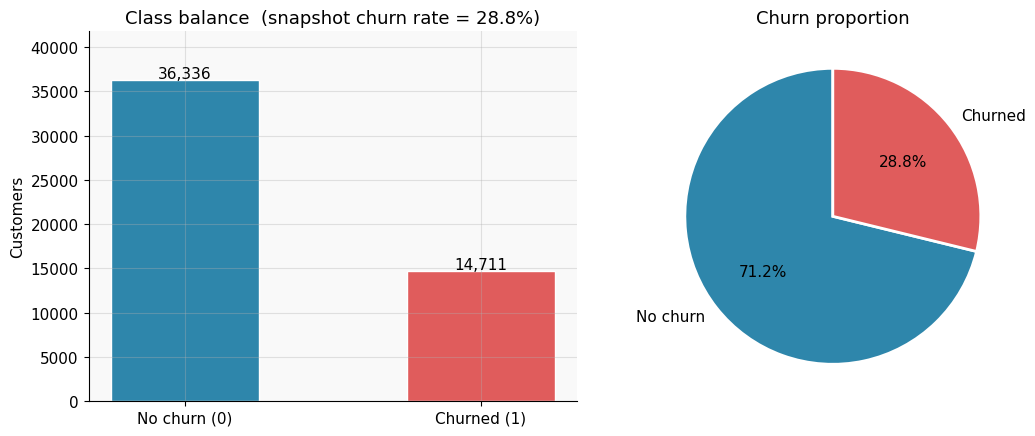

In [6]:
churn_counts = df["churndep"].value_counts().sort_index()
churn_rate   = df["churndep"].mean()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ax = axes[0]
bars = ax.bar(["No churn (0)", "Churned (1)"], churn_counts.values,
              color=[C_BLUE, C_RED], width=0.5, edgecolor="white")
ax.set_title(f"Class balance  (snapshot churn rate = {churn_rate:.1%})")
ax.set_ylabel("Customers")
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 200,
            f"{int(bar.get_height()):,}", ha="center", fontsize=11)
ax.set_ylim(0, churn_counts.max() * 1.15)

ax = axes[1]
ax.pie(churn_counts.values, labels=["No churn", "Churned"],
       colors=[C_BLUE, C_RED], autopct="%1.1f%%", startangle=90,
       wedgeprops={"edgecolor": "white", "linewidth": 2})
ax.set_title("Churn proportion")
plt.tight_layout()
plt.show()

---
## 4. Behavioral Feature Distributions

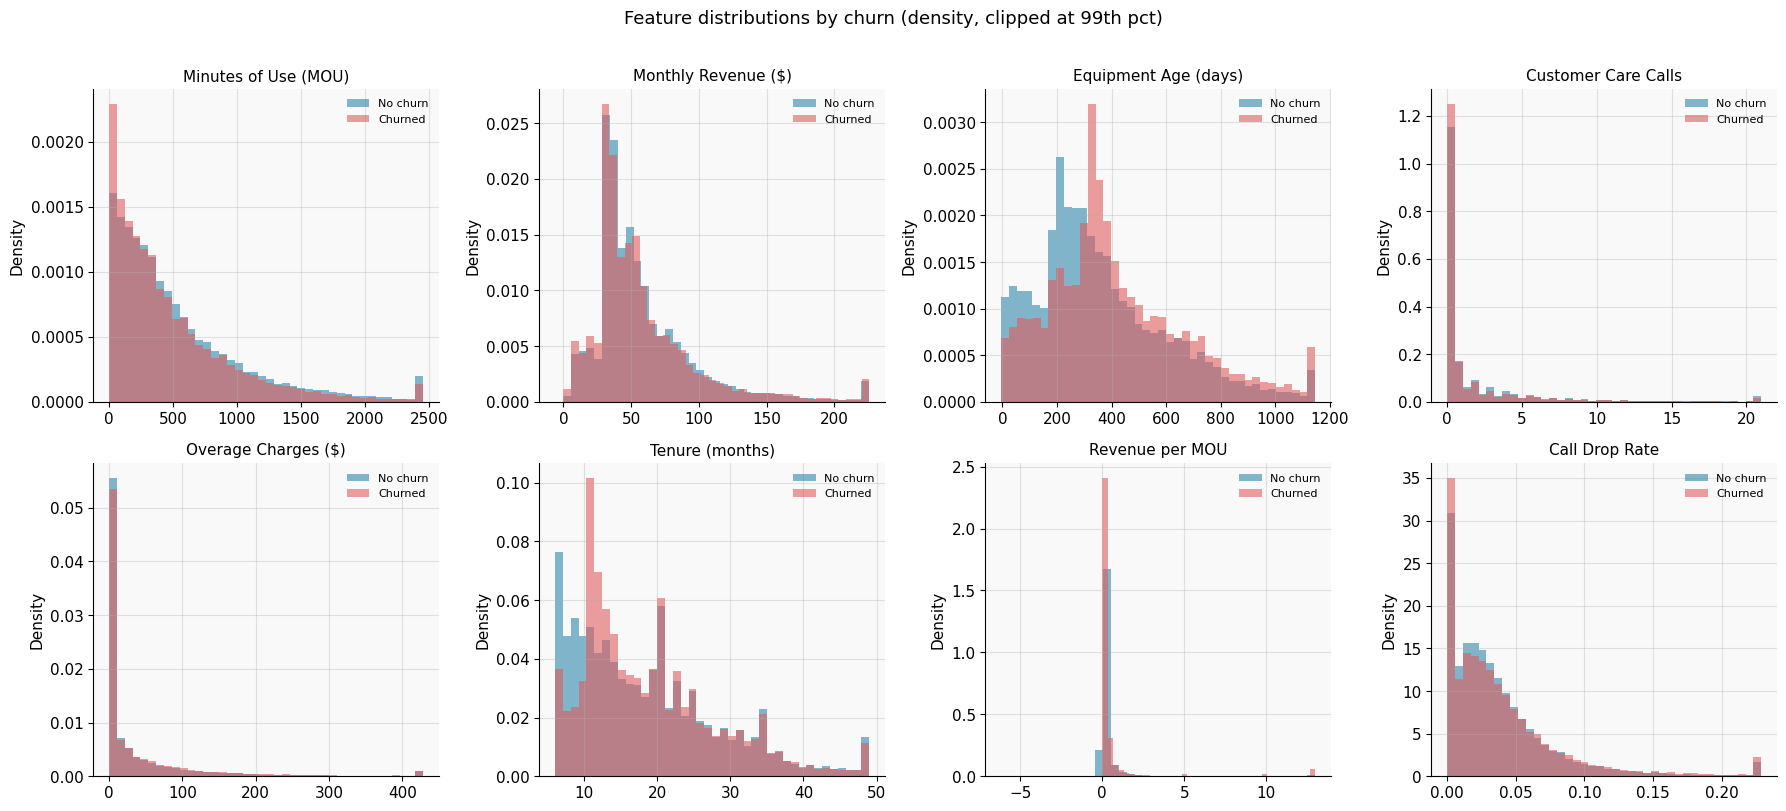

In [7]:
features_to_plot = [
    ("mou",              "Minutes of Use (MOU)"),
    ("revenue",          "Monthly Revenue ($)"),
    ("eqpdays",          "Equipment Age (days)"),
    ("custcare",         "Customer Care Calls"),
    ("overage",          "Overage Charges ($)"),
    ("months",           "Tenure (months)"),
    ("revenue_per_mou",  "Revenue per MOU"),
    ("drop_rate",        "Call Drop Rate"),
]
features_to_plot = [(f, t) for f, t in features_to_plot if f in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, (feat, title) in zip(axes, features_to_plot):
    clip_val = df[feat].quantile(0.99)
    for val, label, color in [(0,"No churn",C_BLUE),(1,"Churned",C_RED)]:
        data = df.loc[df["churndep"]==val, feat].clip(upper=clip_val)
        ax.hist(data, bins=40, alpha=0.6, color=color,
                label=label, edgecolor="none", density=True)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

plt.suptitle("Feature distributions by churn (density, clipped at 99th pct)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 5. New Cell2Cell-Specific Signals

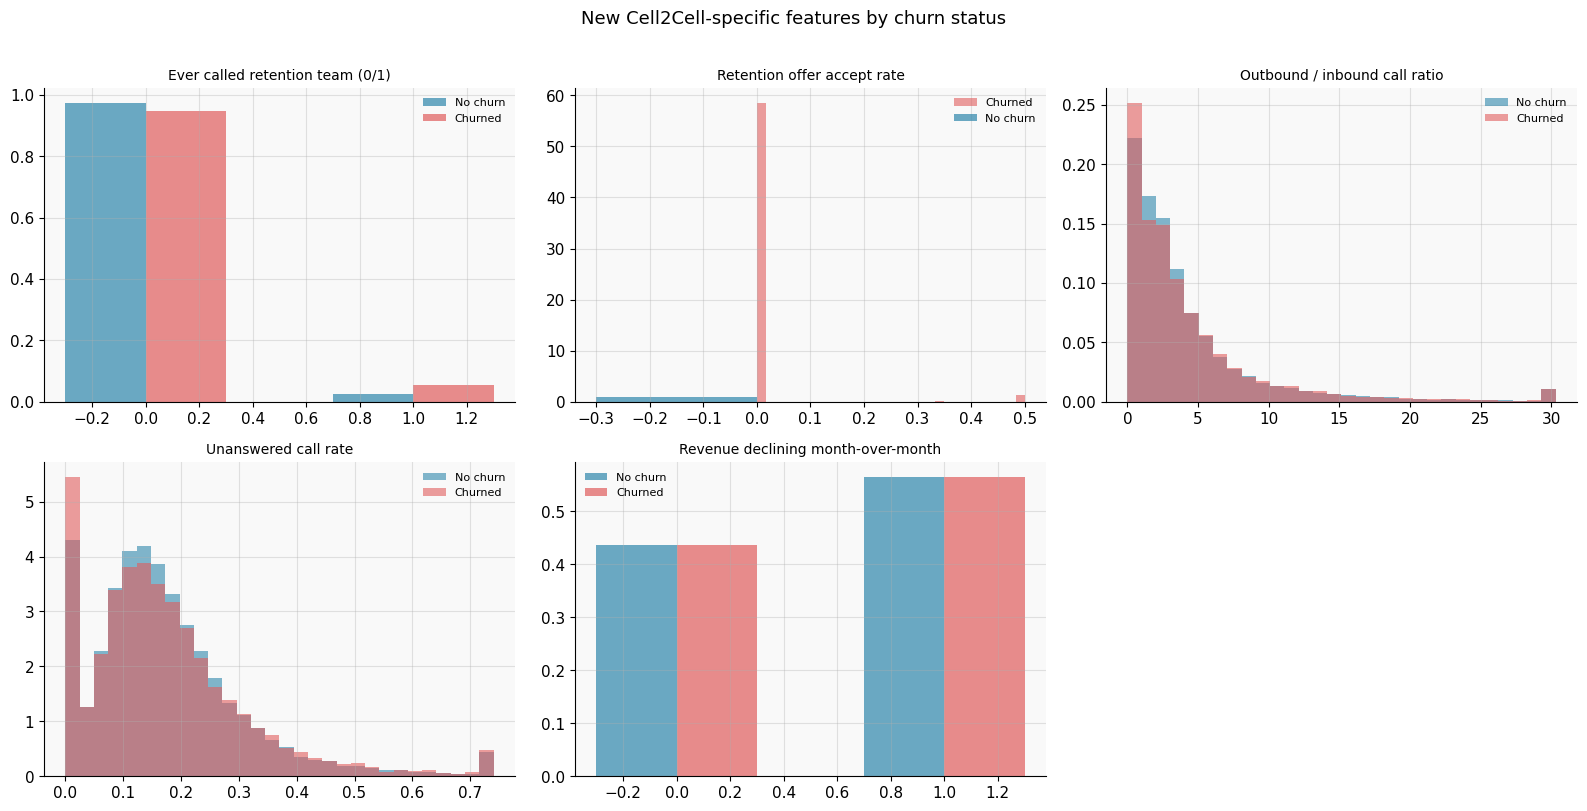

In [8]:
# These features are unique to Cell2Cell and strong churn predictors
new_signals = [
    ("retention_contact",      "Ever called retention team (0/1)"),
    ("retention_accept_rate",  "Retention offer accept rate"),
    ("made_retention_call",    "Customer made retention call (0/1)"),
    ("outbound_ratio",         "Outbound / inbound call ratio"),
    ("unanswered_rate",        "Unanswered call rate"),
    ("revenue_declining",      "Revenue declining month-over-month"),
]
new_signals = [(f, t) for f, t in new_signals if f in df.columns]

if new_signals:
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    axes = axes.flatten()
    for ax, (feat, title) in zip(axes, new_signals):
        clip_val = df[feat].quantile(0.99)
        for val, label, color in [(0,"No churn",C_BLUE),(1,"Churned",C_RED)]:
            data = df.loc[df["churndep"]==val, feat].clip(upper=clip_val)
            if data.nunique() <= 3:
                counts = data.value_counts().sort_index()
                x = counts.index + (0.15 if val==1 else -0.15)
                ax.bar(x, counts.values / counts.sum(),
                       width=0.3, color=color, alpha=0.7, label=label)
            else:
                ax.hist(data, bins=30, alpha=0.6, color=color,
                        label=label, edgecolor="none", density=True)
        ax.set_title(title, fontsize=10)
        ax.legend(fontsize=8)
    for ax in axes[len(new_signals):]:
        ax.set_visible(False)
    plt.suptitle("New Cell2Cell-specific features by churn status",
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print("New signals not found — check column rename in loader.py")

In [9]:
# Summary stats for new signals
summary_feats = [f for f,_ in new_signals] + ["mou","revenue","eqpdays"]
summary_feats = [f for f in summary_feats if f in df.columns]
tbl = df.groupby("churndep")[summary_feats].median().T
tbl.columns = ["No churn (median)", "Churned (median)"]
tbl["Ratio"] = (tbl["Churned (median)"] /
                tbl["No churn (median)"].replace(0, np.nan)).round(2)
print("Median values by churn status:")
print(tbl.to_string())

Median values by churn status:
                       No churn (median)  Churned (median)  Ratio
retention_contact               0.000000          0.000000    NaN
retention_accept_rate           0.000000          0.000000    NaN
outbound_ratio                  2.666667          2.608696   0.98
unanswered_rate                 0.152283          0.149718   0.98
revenue_declining               1.000000          1.000000   1.00
mou                           380.000000        332.000000   0.87
revenue                        48.720000         47.780000   0.98
eqpdays                       310.000000        366.000000   1.18


---
## 6. Feature Correlations with Churn

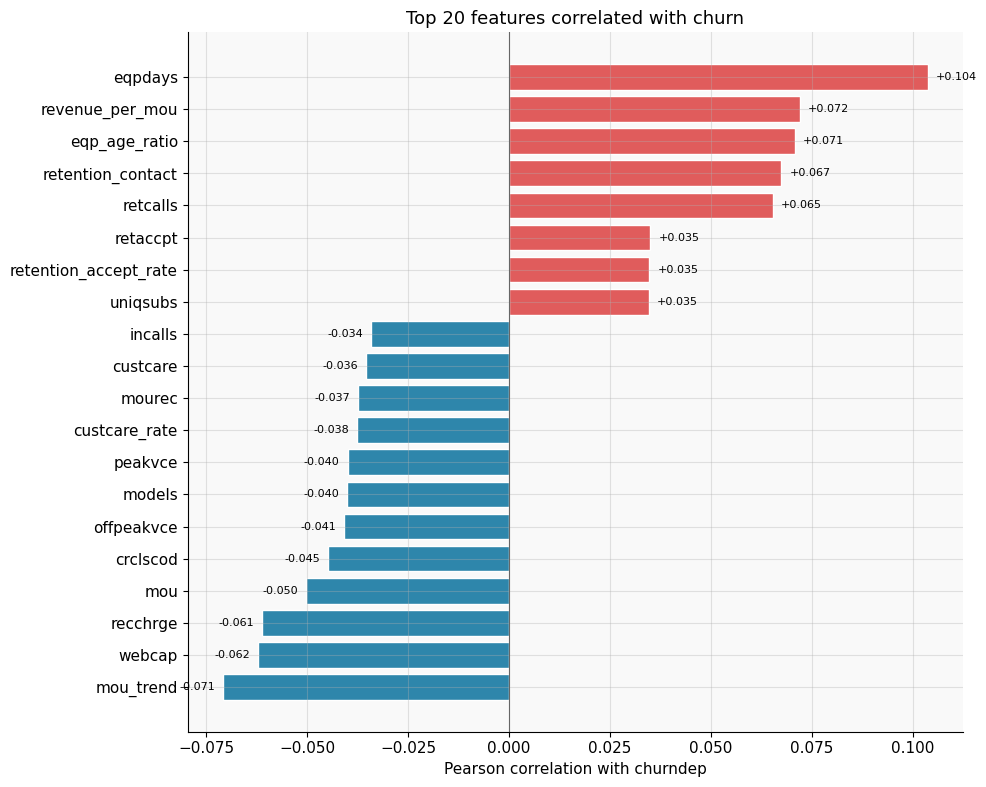

In [10]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols
            if c not in ("churndep",)
            and not c.startswith("churn_")
            and c not in ("days_to_churn","event_observed","cohort")]

corr = df[num_cols + ["churndep"]].corr()["churndep"].drop("churndep").dropna()
top  = corr.abs().nlargest(20)
top_vals = corr[top.index].sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors = [C_RED if v > 0 else C_BLUE for v in top_vals.values]
ax.barh(top_vals.index, top_vals.values, color=colors, edgecolor="white")
ax.axvline(0, color="#666", lw=0.8)
ax.set_xlabel("Pearson correlation with churndep")
ax.set_title("Top 20 features correlated with churn")
for i, (feat, val) in enumerate(top_vals.items()):
    ax.text(val + (0.002 if val >= 0 else -0.002), i,
            f"{val:+.3f}", va="center",
            ha="left" if val >= 0 else "right", fontsize=8)
plt.tight_layout()
plt.show()

---
## 7. Weibull Event Log — Constructing Horizon Labels

In [11]:
from src.data.loader import generate_weibull_event_log

df_events = generate_weibull_event_log(df, shape=1.5, max_days=730, seed=42)

print("New columns added by Weibull event log:")
new_cols = ["days_to_churn","event_observed","churn_30d","churn_60d",
            "churn_90d","churn_180d"]
print(df_events[new_cols].head(8).to_string())

New columns added by Weibull event log:
   days_to_churn  event_observed  churn_30d  churn_60d  churn_90d  churn_180d
0              9               1          1          1          1           1
1            219               1          0          0          0           0
2           1021               0          0          0          0           0
3           1265               0          0          0          0           0
4             43               1          0          1          1           1
5            930               0          0          0          0           0
6           1004               0          0          0          0           0
7           1005               0          0          0          0           0


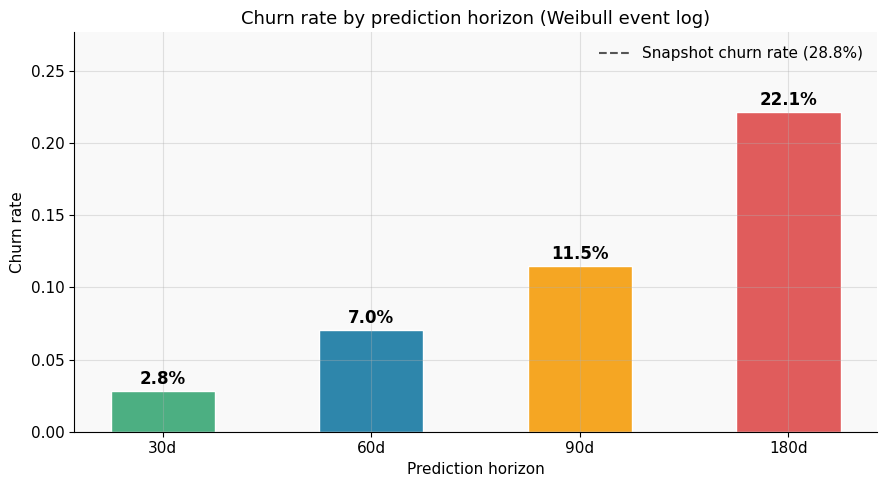


Key: the Weibull label is anchored to churndep.
Feature risk terms (custcare + noise) add within-class variation
but do NOT include eqpdays/months — prevents label memorisation.


In [12]:
horizons = [30, 60, 90, 180]
rates    = {h: df_events[f"churn_{h}d"].mean() for h in horizons}
snapshot = df_events["churndep"].mean()

fig, ax = plt.subplots(figsize=(9, 5))
colors_h = [C_GREEN, C_BLUE, C_ORANGE, C_RED]
bars = ax.bar([f"{h}d" for h in horizons], list(rates.values()),
              color=colors_h, width=0.5, edgecolor="white")
ax.axhline(snapshot, ls="--", color="#555", lw=1.5,
           label=f"Snapshot churn rate ({snapshot:.1%})")
for bar, (h, r) in zip(bars, rates.items()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f"{r:.1%}", ha="center", fontsize=12, fontweight="bold")
ax.set_xlabel("Prediction horizon")
ax.set_ylabel("Churn rate")
ax.set_title("Churn rate by prediction horizon (Weibull event log)")
ax.set_ylim(0, max(rates.values()) * 1.25)
ax.legend()
plt.tight_layout()
plt.show()

print("\nKey: the Weibull label is anchored to churndep.")
print("Feature risk terms (custcare + noise) add within-class variation")
print("but do NOT include eqpdays/months — prevents label memorisation.")

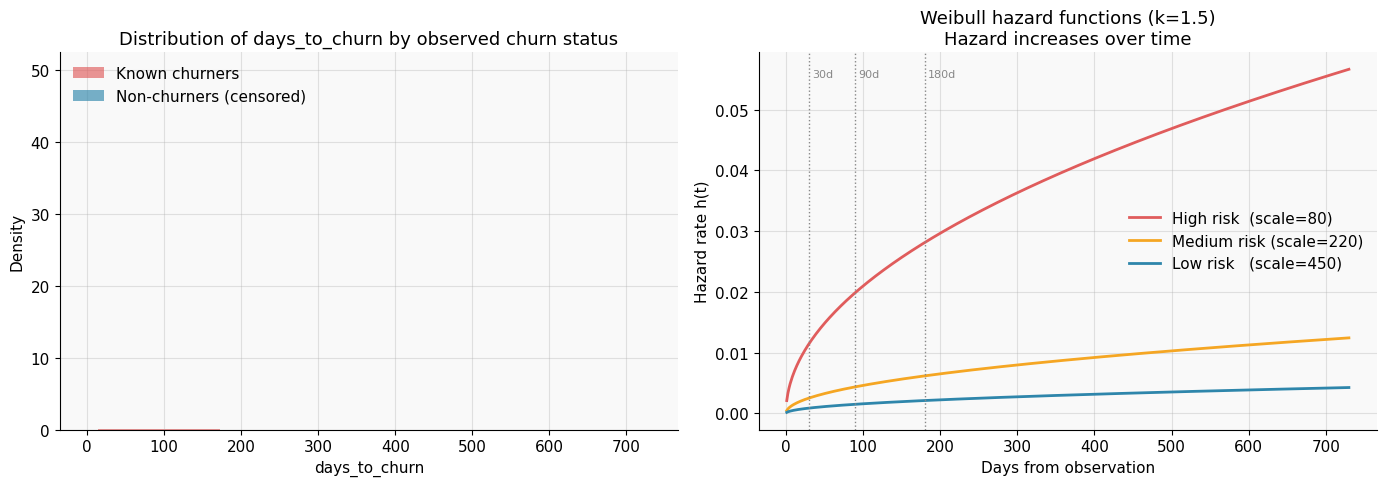

In [13]:
# Visualise Weibull hazard shapes — why k=1.5 is realistic for telecom
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for val, label, color in [(1,"Known churners",C_RED),(0,"Non-churners (censored)",C_BLUE)]:
    data = df_events.loc[df_events["churndep"]==val,
                         "days_to_churn"].clip(0, 730)
    ax.hist(data, bins=50, alpha=0.65, color=color,
            label=label, density=True, edgecolor="none")
ax.set_xlabel("days_to_churn")
ax.set_ylabel("Density")
ax.set_title("Distribution of days_to_churn by observed churn status")
ax.legend()

ax = axes[1]
t = np.linspace(1, 730, 500)
for scale, label, color in [
    (80,  "High risk  (scale=80)",  C_RED),
    (220, "Medium risk (scale=220)", C_ORANGE),
    (450, "Low risk   (scale=450)", C_BLUE),
]:
    k = 1.5
    hazard = (k / scale) * (t / scale) ** (k - 1)
    ax.plot(t, hazard, color=color, lw=2, label=label)
ax.set_xlabel("Days from observation")
ax.set_ylabel("Hazard rate h(t)")
ax.set_title("Weibull hazard functions (k=1.5)\nHazard increases over time")
ax.legend()
for h in [30, 90, 180]:
    ax.axvline(h, ls=":", color="#888", lw=1)
    ax.text(h+4, ax.get_ylim()[1]*0.93, f"{h}d", fontsize=8, color="#888")

plt.tight_layout()
plt.show()

---
## 8. EDA Summary

| Finding | Implication |
|---|---|
| ~29% snapshot churn, ~11.5% at 90d horizon | Label driven by Weibull; model learns horizon-specific risk |
| Retention contacts strongly differentiate churners | `retention_contact`, `made_retention_call` are top features |
| Revenue per MOU higher for churners | Paying more, using less — a disengagement signal |
| Equipment age elevated for churners | Contract cycle + upgrade lag |
| Outbound ratio lower for churners | Passive disengagement before churn |

**Next:** `02_modeling.ipynb`
